
Batch Gradient Descent Coefficients:
Beta 0: 4682892.268213831
Beta 1: 513384.2445805349
Beta 2: 112608.70820532452
Beta 3: 487104.88015330303
Beta 4: 371969.3321682636
Beta 5: 159159.23841358593
Beta 6: 126762.29313784829
Beta 7: 152461.72470474895
Beta 8: 173857.90494943663
Beta 9: 403125.72192338406
Beta 10: 246049.70153335296
Beta 11: 276433.2059002341
Beta 12: -17889.355199477453
Beta 13: -187167.6251200324

Mini-Batch Gradient Descent Coefficients:
Beta 0: 4707210.673156031
Beta 1: 441822.0240942655
Beta 2: 37303.49454614369
Beta 3: 433384.1713976469
Beta 4: 431236.5827227878
Beta 5: 120824.18406105372
Beta 6: -46744.91121107138
Beta 7: 93274.95567527451
Beta 8: 200212.32345815527
Beta 9: 467970.45253941475
Beta 10: 126104.92665099946
Beta 11: 337814.43263812334
Beta 12: 29645.771766321475
Beta 13: -149303.89905459562


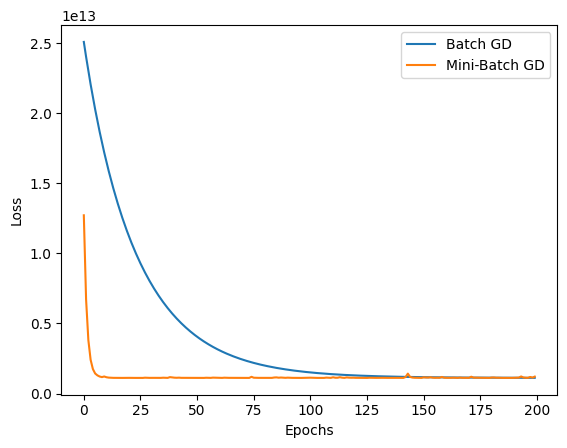

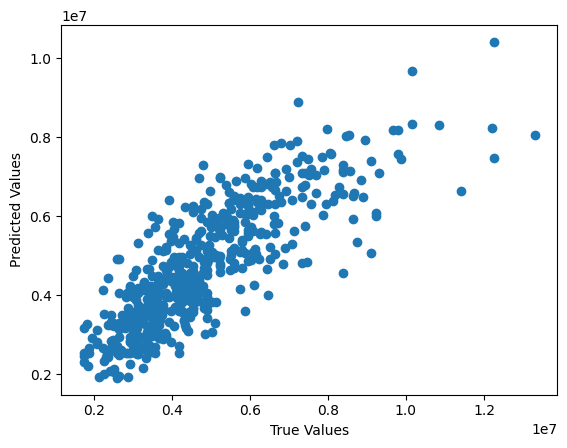

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Housing.csv")

binary_cols = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning', 'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

df = df.astype(float)

X = df.drop("price", axis=1).values
y = df["price"].values.reshape(-1, 1)

X = (X - X.mean(axis=0)) / X.std(axis=0)

m, n = X.shape

X = np.hstack((np.ones((m, 1)), X))

def compute_loss(X, y, beta):
    predictions = X @ beta
    return np.mean((y - predictions) ** 2)

def batch_gradient_descent(X, y, lr=0.01, epochs=200):
    m, n = X.shape
    beta = np.zeros((n, 1))
    loss_history = []

    for epoch in range(epochs):
        predictions = X @ beta
        gradient = (-2/m) * X.T @ (y - predictions)

        beta -= lr * gradient
        loss_history.append(compute_loss(X, y, beta))

    return beta, loss_history

def mini_batch_gradient_descent(X, y, lr=0.01, epochs=200, batch_size=32):
    m, n = X.shape
    beta = np.zeros((n, 1))
    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            batch_m = len(X_batch)

            predictions = X_batch @ beta
            gradient = (-2/batch_m) * X_batch.T @ (y_batch - predictions)

            beta -= lr * gradient

        loss_history.append(compute_loss(X, y, beta))

    return beta, loss_history

beta_bgd, loss_bgd = batch_gradient_descent(X, y)
beta_mbgd, loss_mbgd = mini_batch_gradient_descent(X, y)

print("\nBatch Gradient Descent Coefficients:")
for i, b in enumerate(beta_bgd):
    print(f"Beta {i}: {b[0]}")

print("\nMini-Batch Gradient Descent Coefficients:")
for i, b in enumerate(beta_mbgd):
    print(f"Beta {i}: {b[0]}")


# Plot loss comparison
plt.figure()
plt.plot(loss_bgd, label="Batch GD")
plt.plot(loss_mbgd, label="Mini-Batch GD")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Predictions
pred_bgd = X @ beta_bgd

plt.figure()
plt.scatter(y, pred_bgd)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()
